# 1. Loading and Preprocessing

## 1.1. Loading Dataset

In [ ]:
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amerzishminha/forest-fire-smoke-and-non-fire-image-dataset")
dataset_root = os.path.join(path, 'FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET')

print(os.listdir(dataset_root))

100%|██████████| 6.43G/6.43G [01:27<00:00, 79.0MB/s]

Extracting files...


['test', 'train']


In [ ]:
from pathlib import Path

train_root = Path(dataset_root) / "train"

class_dirs = sorted([p for p in train_root.iterdir() if p.is_dir()])
class_names = [p.name for p in class_dirs]
class_to_index = {name: idx for idx, name in enumerate(class_names)}

print("Number of classes:", len(class_names))
print("Class Names:", class_names)

Number of classes: 3
Class Names: ['Smoke', 'fire', 'non fire']


In [ ]:
from pathlib import Path
import numpy as np
import tensorflow as tf

image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

def collect_image_paths(root_dir, class_to_index, image_extensions):
    image_paths = []
    labels = []
    root_dir = Path(root_dir)
    class_dirs = sorted([p for p in root_dir.iterdir() if p.is_dir()])
    for class_dir in class_dirs:
        class_name = class_dir.name
        if class_name not in class_to_index:
            continue
        for img_path in class_dir.rglob("*"):
            if img_path.is_file() and img_path.suffix.lower() in image_extensions:
                image_paths.append(str(img_path))
                labels.append(class_to_index[class_name])
    return np.array(image_paths), np.array(labels, dtype=np.int32)

all_image_paths, all_labels = collect_image_paths(train_root, class_to_index, image_extensions)

print("Label: ", class_names[all_labels[0]])
print("Image Path: ", all_image_paths[0])

Label:  Smoke
Image Path:  /root/.cache/kagglehub/datasets/amerzishminha/forest-fire-smoke-and-non-fire-image-dataset/versions/3/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train/Smoke/Smoke (8599).jpg


## 1.2. Train Validation Split

In [ ]:
val_split = 0.2
rng = np.random.default_rng(42)
train_indices = []
val_indices = []

for class_idx in range(len(class_names)):
    class_indices = np.where(all_labels == class_idx)[0]
    rng.shuffle(class_indices)
    val_count = int(len(class_indices) * val_split)
    val_indices.append(class_indices[:val_count])
    train_indices.append(class_indices[val_count:])


train_indices = np.concatenate(train_indices) if train_indices else np.array([], dtype=np.int64)
val_indices = np.concatenate(val_indices) if val_indices else np.array([], dtype=np.int64)
rng.shuffle(train_indices)
rng.shuffle(val_indices)

train_paths = all_image_paths[train_indices]
train_labels = all_labels[train_indices]
val_paths = all_image_paths[val_indices]
val_labels = all_labels[val_indices]

test_root = Path(dataset_root) / "test"
test_paths, test_labels = collect_image_paths(test_root, class_to_index, image_extensions)

print("Train images:", len(train_paths), "Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Train images: 25366 Validation images: 6340
Test images: 9446


## 1.3. Preprocessing and Tensor Loading

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 3

In [ ]:

def load_and_preprocess_image(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=CHANNELS, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(buffer_size=len(train_paths), seed=42, reshuffle_each_iteration=True)
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE * 2).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.apply(tf.data.experimental.ignore_errors())
test_ds = test_ds.batch(BATCH_SIZE * 2).prefetch(tf.data.AUTOTUNE)

for images, labels in train_ds.take(1):
    print(images.shape)

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


(32, 224, 224, 3)


# 2. Data Visualization and Exploration

## 2.1. Visualizing Random Images

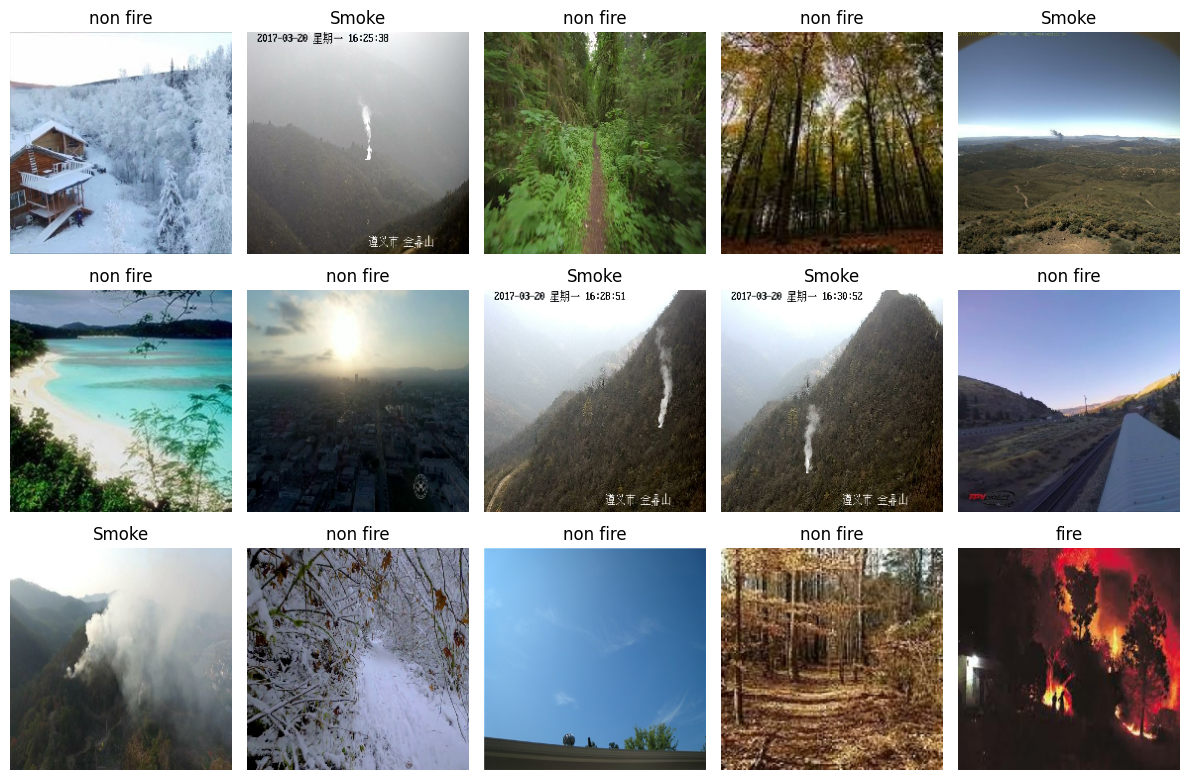

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for i, (image, label) in enumerate(train_ds.unbatch().take(15)):
    ax = plt.subplot(3, 5, i + 1)
    plt.imshow(image.numpy())
    plt.title(class_names[int(label)])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 2.2. Visualizing Class Distribution

/tmp/ipykernel_14118/2356267136.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_names, y=full_counts, palette='Set1')


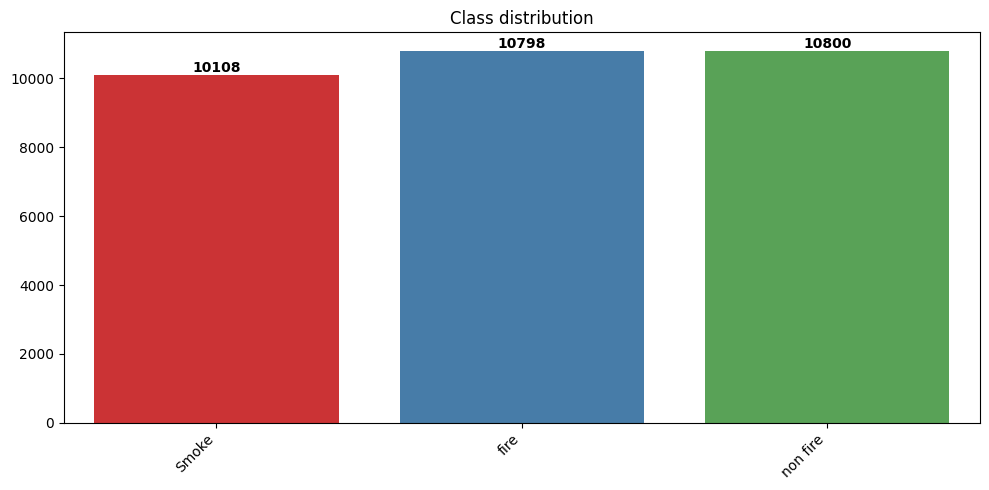

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

full_counts = np.bincount(all_labels, minlength=len(class_names))

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=class_names, y=full_counts, palette='Set1')

# Add numbers above bars
for i, count in enumerate(full_counts):
    ax.text(i, count + 0.5, str(count), ha='center', va='bottom', fontweight='bold')

plt.title("Class distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

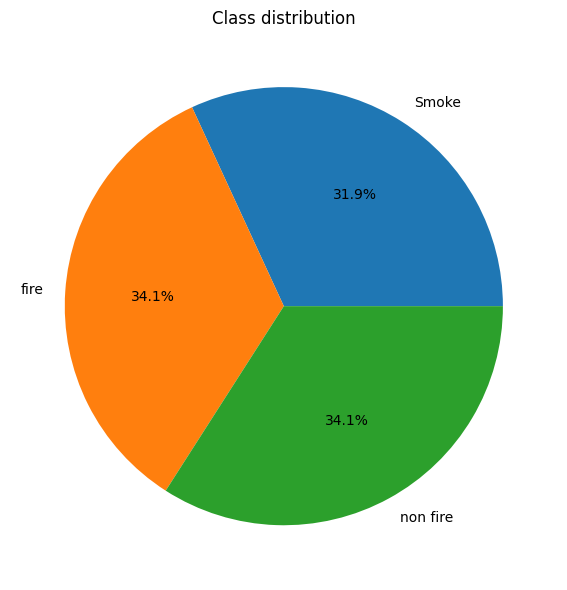

In [ ]:
plt.figure(figsize=(7, 6))
plt.pie(full_counts, labels=class_names, autopct="%1.1f%%")
plt.title("Class distribution")
plt.tight_layout()
plt.show()

# 3. Model

## 3.1. Model Definition

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Dropout, Flatten, MaxPooling2D, Dense
from tensorflow.keras.regularizers import L2

num_classes = len(class_names)

model = Sequential([

    Input((224, 224, 3)),

    # First Convolution Layer
    Conv2D(activation='relu', filters=32, kernel_size=(3, 3), padding='same'),
    Conv2D(activation='relu', filters=32, kernel_size=(3, 3), padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.25),

    # Second Convolution Layer
    Conv2D(activation='relu', filters=64, kernel_size=(3, 3), padding='same'),
    Conv2D(activation='relu', filters=64, kernel_size=(3, 3), padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.25),

    # Third Convolution Layer
    Conv2D(activation='relu', filters=128, kernel_size=(3, 3), padding='same'),
    Conv2D(activation='relu', filters=128, kernel_size=(3, 3), padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.3),

    # Fourth Convolution Layer
    Conv2D(activation='relu', filters=256, kernel_size=(3, 3), padding='same'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),
    Dropout(0.3),

    # Dense Layers
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer = L2(1e-5)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu', kernel_regularizer = L2(1e-5)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## 3.2. Model Callbacks

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.5,
    patience = 2,
    min_lr = 1e-6,
    verbose = 1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience = 5,
    restore_best_weights=True
)


## 3.3. Model Training

In [ ]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 50,
    verbose = True,
    callbacks = [reduce_lr, early_stopping]
)

Epoch 1/50
793/793 ━━━━━━━━━━━━━━━━━━━━ 197s 248ms/step - accuracy: 0.9355 - loss: 0.2059 - val_accuracy: 0.9175 - val_loss: 0.2877 - learning_rate: 0.0010
Epoch 2/50
793/793 ━━━━━━━━━━━━━━━━━━━━ 180s 220ms/step - accuracy: 0.9482 - loss: 0.1764 - val_accuracy: 0.9401 - val_loss: 0.1947 - learning_rate: 0.0010
Epoch 3/50
793/793 ━━━━━━━━━━━━━━━━━━━━ 191s 206ms/step - accuracy: 0.9561 - loss: 0.1614 - val_accuracy: 0.9533 - val_loss: 0.1583 - learning_rate: 0.0010
Epoch 4/50
793/793 ━━━━━━━━━━━━━━━━━━━━ 205s 210ms/step - accuracy: 0.9603 - loss: 0.1577 - val_accuracy: 0.9366 - val_loss: 0.2287 - learning_rate: 0.0010
Epoch 5/50
793/793 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9635 - loss: 0.1482
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
793/793 ━━━━━━━━━━━━━━━━━━━━ 165s 208ms/step - accuracy: 0.9650 - loss: 0.1482 - val_accuracy: 0.9532 - val_loss: 0.1922 - learning_rate: 0.0010
Epoch 6/50
793/793 ━━━━━━━━━━━━━━━━━━━━ 211s 220ms/step - accuracy:

In [ ]:
model.save('CNN_Model.keras')

## 3.4. Visualizing Training

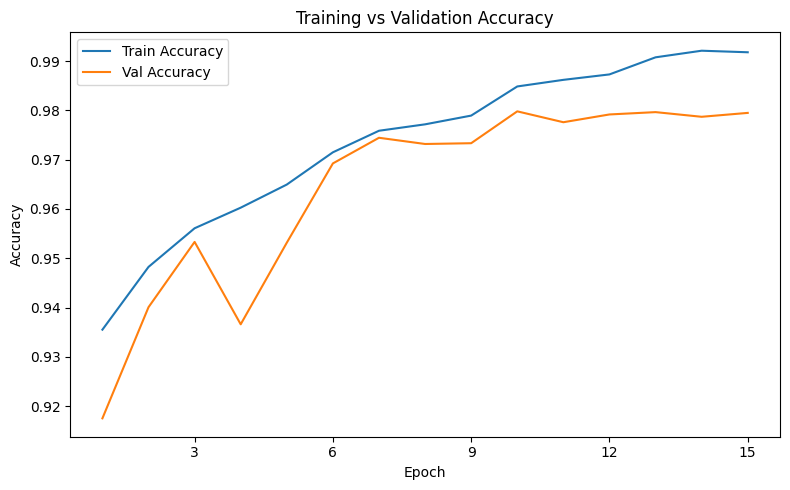

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history.history["accuracy"], label="Train Accuracy")
plt.plot(epochs, history.history["val_accuracy"], label="Val Accuracy")

max_epoch = len(epochs)
tick_step = 3
ticks = list(range(tick_step, max_epoch + 1, tick_step))
if not ticks:
    ticks = list(range(1, max_epoch + 1))
plt.xticks(ticks)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Evaluation

In [ ]:
from sklearn.metrics import classification_report

# Predict on test images
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

y_pred[:5]

148/148 ━━━━━━━━━━━━━━━━━━━━ 76s 508ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


array([0, 0, 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Match labels to filtered test_ds length
y_test = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

In [ ]:
print(f"Test Accuracy: {round(acc, 2) * 100}%")
print(f"Test Precision: {round(prec, 2) * 100}%")
print(f"Test Recall: {round(rec, 2) * 100}%")
print(f"Test F1-score : {round(f1, 2) * 100}%")

Test Accuracy: 99.0%
Test Precision: 99.0%
Test Recall: 99.0%
Test F1-score : 99.0%
